# Ad-hoc анализ покупок сети супермаркетов

Данные: dunnhumby «The Complete Journey» — покупки 2 500 домохозяйств за 102 недели.
Все числа ниже берутся из `reports/results.json`, который генерирует `make analyze`;
ноутбук только показывает результаты и формулирует выводы.

In [1]:
import json

import pandas as pd
from IPython.display import Image, Markdown, display

from retail_analysis.config import PROJECT_ROOT, load_config

config = load_config()
results = json.loads(config.paths.results_file.read_text(encoding="utf-8"))
data = results["data"]
business = results["business"]
rfm = results["rfm"]
cohorts = results["cohorts"]
churn = results["churning_loyal"]
promo = results["promo"]
estimates = promo["estimates"]
window = data["analysis_window"]
segments = pd.DataFrame(rfm["segments"]).set_index("segment")
groups = pd.DataFrame(churn["groups"]).set_index("household_group")
department_mix = pd.DataFrame(churn["department_mix"])
demographics = pd.DataFrame(churn["demographic_tests"])
pd.options.display.float_format = "{:,.3f}".format


def show(figure_key: str, section: dict) -> None:
    display(Image(filename=str(PROJECT_ROOT / section["figures"][figure_key])))

## 1. Краткие выводы

In [2]:
units = estimates["units"]
with_display = estimates["units_display_control"]
revenue = estimates["revenue"]
cannibal = estimates["cannibalization_units"]
alpha = 1 - promo["confidence_level"]
champions = segments.iloc[0]
at_risk = segments.loc["Под угрозой ухода"]
churning = groups.loc["churning_loyal"]
retention = cohorts["average_retention_by_period"]
significant_mix = department_mix[department_mix["significant"]]
mix_text = ", ".join(
    f"{row.department} {row.difference_pp:+.1f} п.п." for row in significant_mix.itertuples()
)
cannibal_text = (
    f"значимой каннибализации соседних товаров нет: {cannibal['effect_pct']:+.1f}% "
    f"(95% ДИ от {cannibal['effect_pct_ci_low']:+.1f}% до {cannibal['effect_pct_ci_high']:+.1f}%)"
    if cannibal["p_value"] >= alpha
    else f"продажи соседних товаров меняются на {cannibal['effect_pct']:+.1f}% "
    f"(95% ДИ от {cannibal['effect_pct_ci_low']:+.1f}% до {cannibal['effect_pct_ci_high']:+.1f}%)"
)
tw = business["trend_weeks"]
display(Markdown(f'''
1. **Выручка растет за счет среднего чека, а не трафика.** Последние {tw} недель против первых {tw}:
   выручка {business["revenue_change_last_vs_first"]:+.0%}, средний чек {business["basket_value_change_last_vs_first"]:+.0%},
   число чеков {business["baskets_change_last_vs_first"]:+.0%}, активных домохозяйств {business["active_households_change_last_vs_first"]:+.0%}.
   *Рекомендация:* разложить рост чека на цену и количество товаров и отдельно ставить цели по частоте визитов.
2. **Выручка сконцентрирована у ядра клиентов.** {rfm["top_customers_share"]:.0%} домохозяйств с наибольшими тратами дают
   {rfm["top_customers_revenue_share"]:.0%} выручки; сегмент «{champions.name}» — {champions["household_share"]:.0%} клиентов и
   {champions["revenue_share"]:.0%} выручки. *Рекомендация:* удерживать «Чемпионов» персональными предложениями, а сегмент
   «Под угрозой ухода» ({at_risk["household_share"]:.0%} клиентов, {at_risk["revenue_share"]:.0%} выручки) — реактивировать в первую очередь.
3. **Удержание высокое и не снижается со временем.** В следующем 4-недельном периоде покупает {retention["1"]:.0%} когорты,
   через год (13 периодов) — {retention["13"]:.0%}. *Рекомендация:* в этой панели главный рычаг — частота и чек активной базы,
   а не возврат ушедших; на полной клиентской базе метрику нужно перепроверить (см. ограничения).
4. **{churn["churning_households"]} из {churn["loyal_households"]} лояльных домохозяйств уходят.** За последние {churn["recent_weeks"]} недель
   число чеков у них упало на {churn["churning_basket_drop"]:.0%}, а их доля выручки — с {churn["churning_baseline_revenue_share"]:.1%}
   до {churn["churning_recent_revenue_share"]:.1%}. До ухода у них был ниже средний чек (медиана {churn["basket_value_comparison"]["churning_median"]:.0f} $
   против {churn["basket_value_comparison"]["stable_median"]:.0f} $) и другая структура корзины ({mix_text}).
   *Рекомендация:* триггерная кампания, когда частота покупок лояльного клиента падает вдвое к его норме.
5. **Каталог связан с ростом продаж товара в неделю промо на {units["effect_pct"]:.0f}% в штуках и {revenue["effect_pct"]:.0f}% в выручке**,
   но {promo["concurrent_display_share"]["treated"]:.0%} товаров каталога в ту же неделю стоят в выкладке (в контроле —
   {promo["concurrent_display_share"]["control"]:.0%}); с поправкой на выкладку эффект {with_display["effect_pct"]:.0f}%
   (95% ДИ {with_display["effect_pct_ci_low"]:.0f}–{with_display["effect_pct_ci_high"]:.0f}%). {cannibal_text[0].upper() + cannibal_text[1:]}.
   *Рекомендация:* оценивать каталог и выкладку как связку и проверить их раздельный эффект A/B-тестом на магазинах.
'''))


1. **Выручка растет за счет среднего чека, а не трафика.** Последние 13 недель против первых 13:
   выручка +15%, средний чек +18%,
   число чеков -3%, активных домохозяйств +2%.
   *Рекомендация:* разложить рост чека на цену и количество товаров и отдельно ставить цели по частоте визитов.
2. **Выручка сконцентрирована у ядра клиентов.** 20% домохозяйств с наибольшими тратами дают
   54% выручки; сегмент «Чемпионы» — 21% клиентов и
   46% выручки. *Рекомендация:* удерживать «Чемпионов» персональными предложениями, а сегмент
   «Под угрозой ухода» (13% клиентов, 13% выручки) — реактивировать в первую очередь.
3. **Удержание высокое и не снижается со временем.** В следующем 4-недельном периоде покупает 80% когорты,
   через год (13 периодов) — 81%. *Рекомендация:* в этой панели главный рычаг — частота и чек активной базы,
   а не возврат ушедших; на полной клиентской базе метрику нужно перепроверить (см. ограничения).
4. **70 из 491 лояльных домохозяйств уходят.** За последние 12 недель
   число чеков у них упало на 75%, а их доля выручки — с 6.5%
   до 2.1%. До ухода у них был ниже средний чек (медиана 28 $
   против 40 $) и другая структура корзины (PRODUCE -1.3 п.п., MEAT-PCKGD +1.0 п.п.).
   *Рекомендация:* триггерная кампания, когда частота покупок лояльного клиента падает вдвое к его норме.
5. **Каталог связан с ростом продаж товара в неделю промо на 100% в штуках и 84% в выручке**,
   но 90% товаров каталога в ту же неделю стоят в выкладке (в контроле —
   45%); с поправкой на выкладку эффект 48%
   (95% ДИ 45–52%). Значимой каннибализации соседних товаров нет: +2.2% (95% ДИ от -0.4% до +4.8%).
   *Рекомендация:* оценивать каталог и выкладку как связку и проверить их раздельный эффект A/B-тестом на магазинах.


## 2. Данные и подготовка

**Источник.** dunnhumby «The Complete Journey», зеркало на Mendeley Data (CC BY 4.0). Файлы
скачиваются по прямым ссылкам и сверяются по SHA-256 (`make download`).

**Подготовка (PySpark).** CSV читаются с явной схемой, колонки приводятся к `snake_case`,
удаляются полные дубликаты и строки чеков с `quantity = 0` или `sales_value <= 0`.
Таблицы сохраняются в Parquet, `causal_data` партиционирована по `week_no`. Там же строится
агрегат «товар × неделя» с продажами и долей магазинов, разместивших товар в каталоге или выкладке.

In [3]:
tables = pd.DataFrame(data["tables"]).T
display(tables)
display(Markdown(
    f"Из таблицы чеков удалено {data['removed_transaction_share']:.2%} строк. "
    f"После очистки: {data['households']} домохозяйств, {data['baskets']} чеков, "
    f"{data['products']} товаров, {data['stores']} магазинов, {data['weeks']} недель."
))

,rows_raw,duplicates_removed,zero_quantity_removed,non_positive_sales_removed,rows_clean
transaction_data,"2,595,732.000",0.000,"14,466.000","4,451.000","2,576,815.000"
product,"92,353.000",0.000,NaN,NaN,"92,353.000"
hh_demographic,801.000,0.000,NaN,NaN,801.000
causal_data,"36,786,524.000",0.000,NaN,NaN,"36,786,524.000"


Из таблицы чеков удалено 0.73% строк. После очистки: 2500 домохозяйств, 275539 чеков, 91905 товаров, 581 магазинов, 102 недель.

**Проверки качества.** Критическая ошибка останавливает пайплайн; некритичные находки только логируются.

In [4]:
display(pd.DataFrame(data["quality_checks"]))

,name,passed,critical,details
0,no_nulls_transaction_data,True,True,"no nulls in household_key, basket_id, day, pro..."
1,no_nulls_product,True,True,no nulls in product_id
2,no_nulls_hh_demographic,True,True,no nulls in household_key
3,no_nulls_causal_data,True,True,"no nulls in product_id, store_id, week_no, dis..."
4,products_in_reference,True,True,0 product_id values from transactions are miss...
5,product_hierarchy_sold,True,True,"0 sold products without department, commodity_..."
6,product_hierarchy_reference,False,False,"15 reference products without department, comm..."
7,week_range_transaction_data,True,True,"observed weeks 1-102, allowed 1-102"
8,week_range_causal_data,True,True,"observed weeks 9-101, allowed 1-102"


**Окно анализа.** Календарных дат нет, только номер дня и недели. Домохозяйства входят в панель
постепенно, поэтому в первые недели активных покупателей мало, а последняя неделя может быть
неполной. Окно начинается с первой недели, после которой число активных домохозяйств не опускается
ниже заданной доли медианы, и заканчивается последней полной (7 дней) неделей.

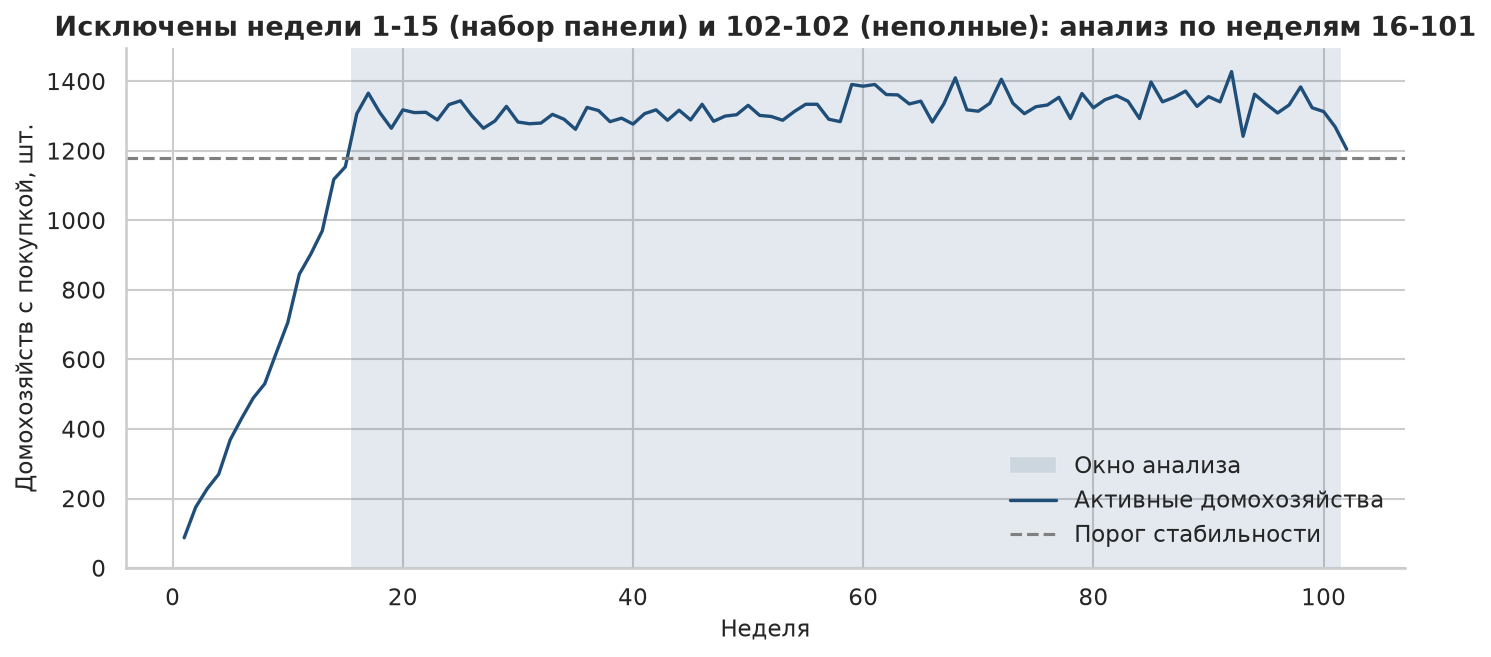

В последней неделе 102 данные за 6 дн. Порог — 90% медианы недельной активности (1179 домохозяйств). Анализ ведется по неделям 16–101; когортный анализ использует все недели до 101, потому что когорта определяется по первой покупке.

In [5]:
show("analysis_window", data)
last_week = data["weekly_activity"][-1]
display(Markdown(
    f"В последней неделе {last_week['week_no']} данные за {last_week['days']} дн. Порог — {data['stable_activity_ratio']:.0%} медианы недельной активности "
    f"({window['active_households_threshold']:.0f} домохозяйств). Анализ ведется по неделям "
    f"{window['start_week']}–{window['end_week']}; когортный анализ использует все недели до {window['end_week']}, "
    f"потому что когорта определяется по первой покупке."
))

## 3. Как устроен бизнес?

**Вопрос.** Как меняются выручка, число чеков, активные клиенты и средний чек; какие категории
приносят выручку.

**Метод.** `sql/01_weekly_kpi.sql` — недельные KPI с изменением к прошлой неделе (`LAG`);
`sql/02_category_share.sql` — доли отделов и товарных категорий (`SUM() OVER`, `ROW_NUMBER`).
Тренд — отношение средних последних и первых недель окна.

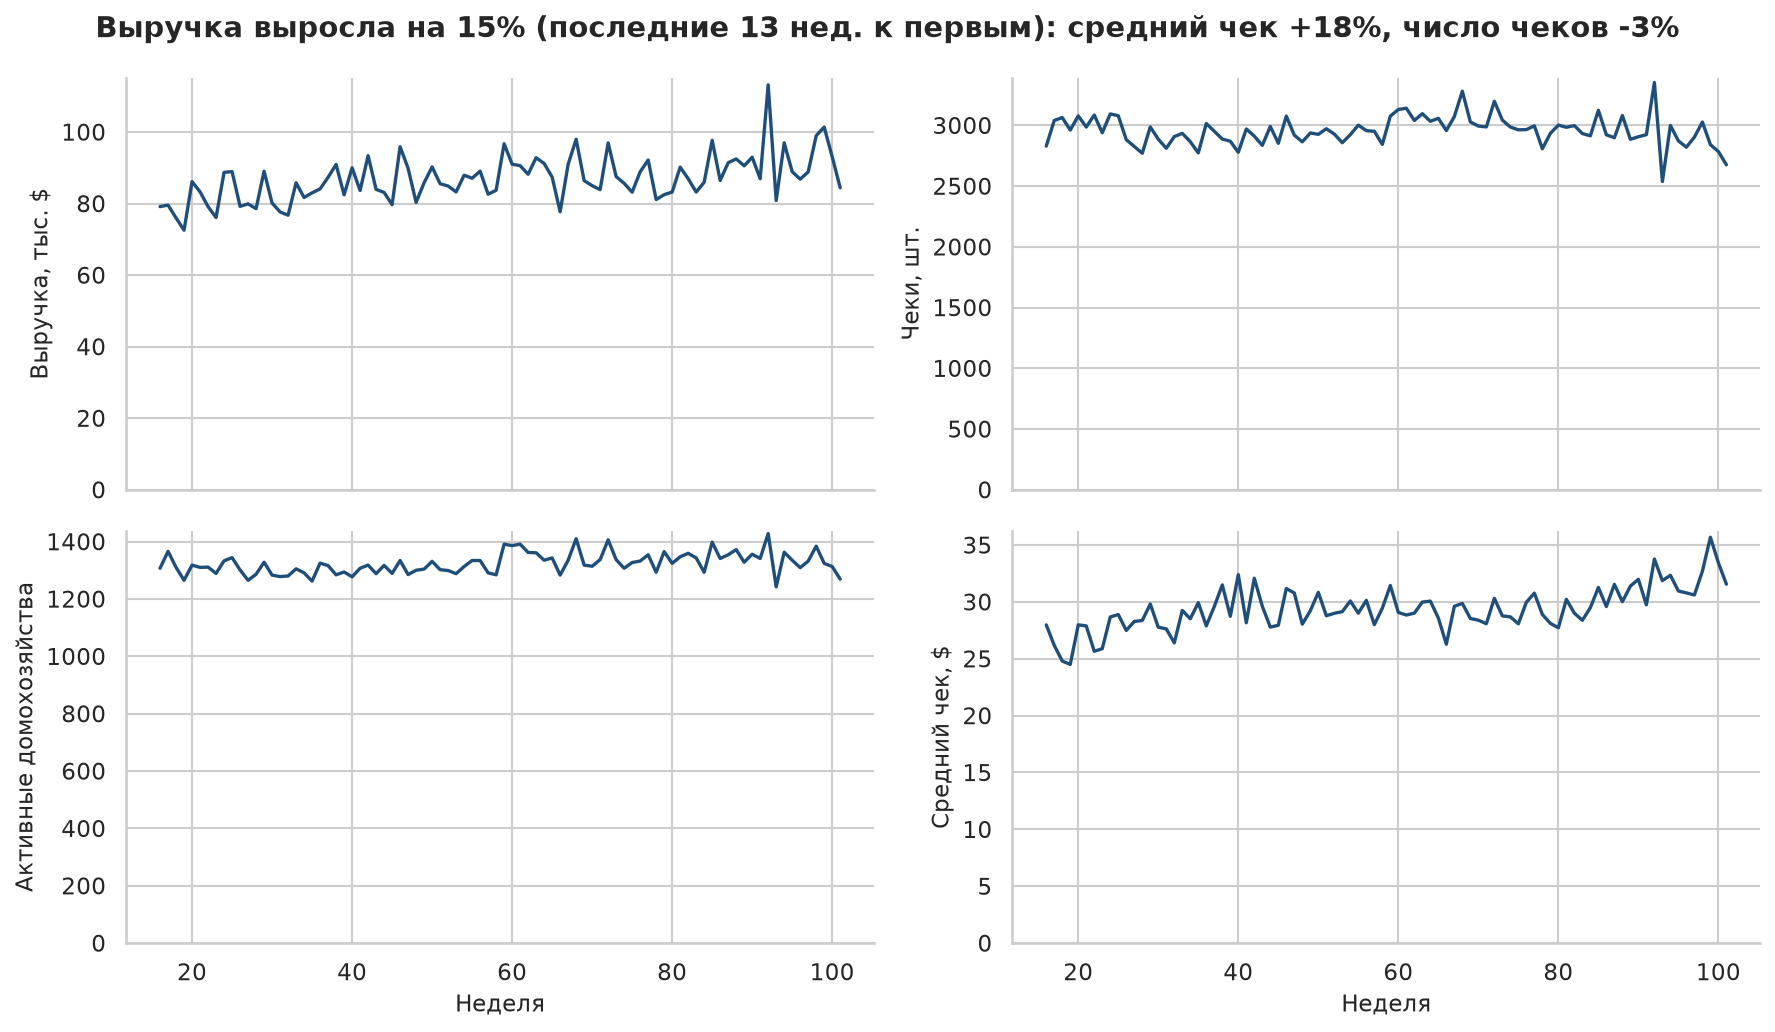

За окно анализа выручка составила 7.46 млн $ (254174 чеков). В среднем за неделю: 86.8 тыс. $ выручки, 2956 чеков, 1323 активных домохозяйств, средний чек 29.37 $. Выручка выросла на 15% почти полностью за счет среднего чека (+18%), число чеков изменилось на -3%.

In [6]:
show("weekly_kpi", business)
display(Markdown(
    f"За окно анализа выручка составила {business['total_revenue'] / 1e6:.2f} млн $ "
    f"({business['total_baskets']} чеков). В среднем за неделю: {business['avg_weekly_revenue'] / 1e3:.1f} тыс. $ выручки, "
    f"{business['avg_weekly_baskets']:.0f} чеков, {business['avg_weekly_active_households']:.0f} активных домохозяйств, "
    f"средний чек {business['avg_basket_value']:.2f} $. Выручка выросла на {business['revenue_change_last_vs_first']:.0%} "
    f"почти полностью за счет среднего чека ({business['basket_value_change_last_vs_first']:+.0%}), "
    f"число чеков изменилось на {business['baskets_change_last_vs_first']:+.0%}."
))

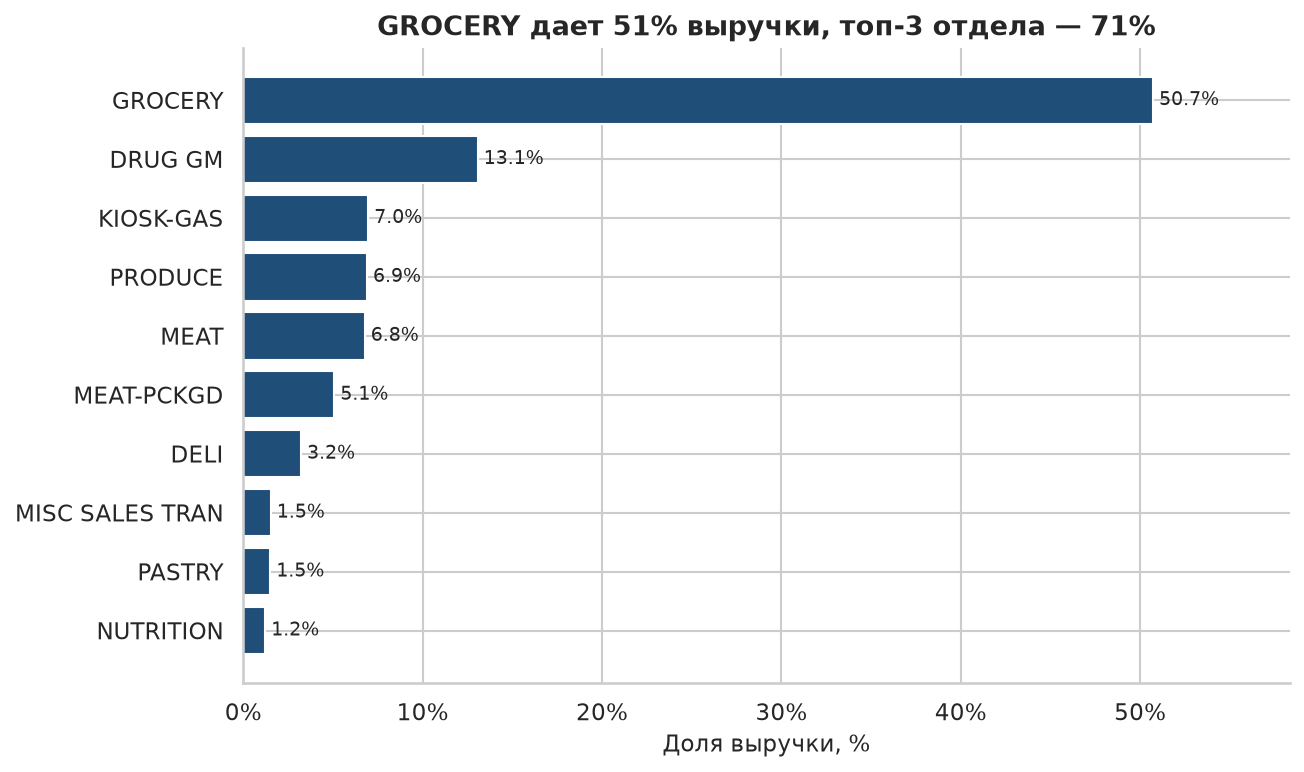

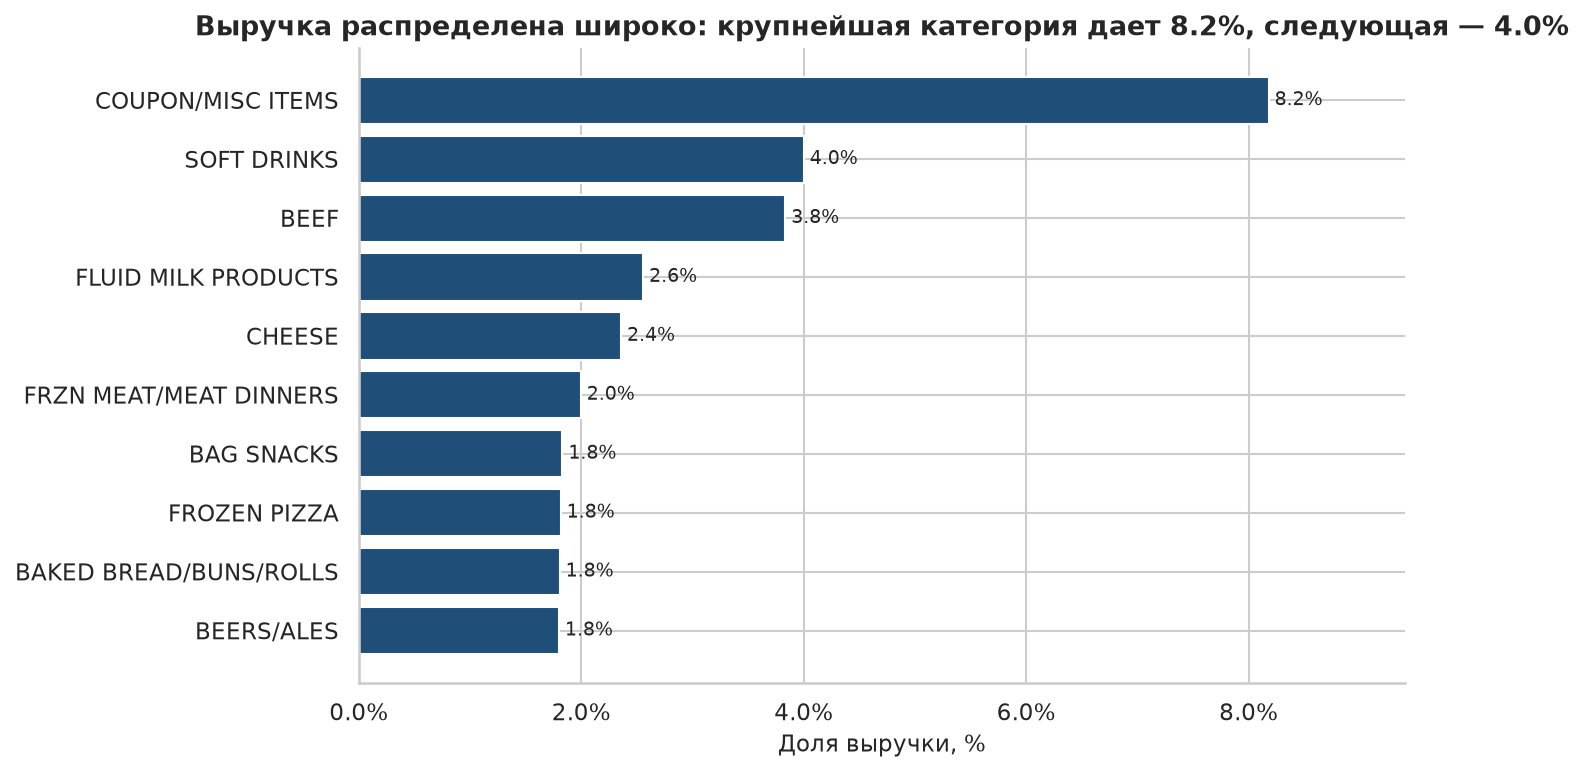

GROCERY дает 50.7% выручки, три крупнейших отдела — 71%. Крупнейшая товарная категория COUPON/MISC ITEMS (8.2%) — в основном топливо АЗС (подкатегория GASOLINE-REG UNLEADED), то есть не продуктовая корзина; среди продуктов выручка распределена широко.

In [7]:
show("departments", business)
show("commodities", business)
top_department = business["top_departments"][0]
top_commodity = business["top_commodities"][0]
display(Markdown(
    f"{top_department['category']} дает {top_department['revenue_share']:.1%} выручки, три крупнейших отдела — "
    f"{business['top3_department_share']:.0%}. Крупнейшая товарная категория {top_commodity['category']} "
    f"({top_commodity['revenue_share']:.1%}) — в основном топливо АЗС (подкатегория GASOLINE-REG UNLEADED), "
    f"то есть не продуктовая корзина; среди продуктов выручка распределена широко."
))

## 4. Какие есть клиентские сегменты?

**Метод.** `sql/03_rfm.sql`: Recency — недель от последней покупки до конца окна, Frequency —
число чеков, Monetary — выручка; баллы 1–5 через `NTILE(5)` (5 — лучшее значение). При равной
давности в неделях баллы R различаются по дню последней покупки. Сегменты задаются в
`config.yaml`, правило — первое совпадение сверху вниз:

In [8]:
display(Markdown(
    f"В последнюю неделю окна покупали {rfm['share_bought_in_last_week']:.0%} домохозяйств, поэтому "
    f"баллы R 3–5 у многих различаются только днем последней покупки."
))
rules = pd.DataFrame(
    [
        {"сегмент": rule.name, "R": rule.recency, "F": rule.frequency, "M": rule.monetary}
        for rule in config.rfm.segments
    ]
)
display(rules)
display(segments)

В последнюю неделю окна покупали 51% домохозяйств, поэтому баллы R 3–5 у многих различаются только днем последней покупки.

,сегмент,R,F,M
0,Чемпионы,"(4, 5)","(4, 5)","(4, 5)"
1,Лояльные,"(3, 5)","(3, 5)","(1, 5)"
2,Перспективные,"(4, 5)","(1, 2)","(1, 5)"
3,Под угрозой ухода,"(1, 2)","(3, 5)","(1, 5)"
4,Спящие,"(1, 2)","(1, 2)","(1, 5)"
5,Середняки,"(1, 5)","(1, 5)","(1, 5)"


,households,household_share,avg_basket_value,avg_frequency,avg_recency_weeks,revenue,revenue_share
segment,,,,,,,
Чемпионы,512,0.205,30.131,223.936,0.000,"3,454,678.270",0.463
Лояльные,652,0.262,27.932,117.563,0.224,"2,141,038.000",0.287
Перспективные,178,0.071,34.672,34.399,0.000,"212,294.470",0.028
Под угрозой ухода,331,0.133,27.680,104.810,4.281,"960,266.220",0.129
Спящие,667,0.268,31.625,25.484,9.402,"537,554.750",0.072
Середняки,153,0.061,31.343,33.039,0.523,"158,438.760",0.021


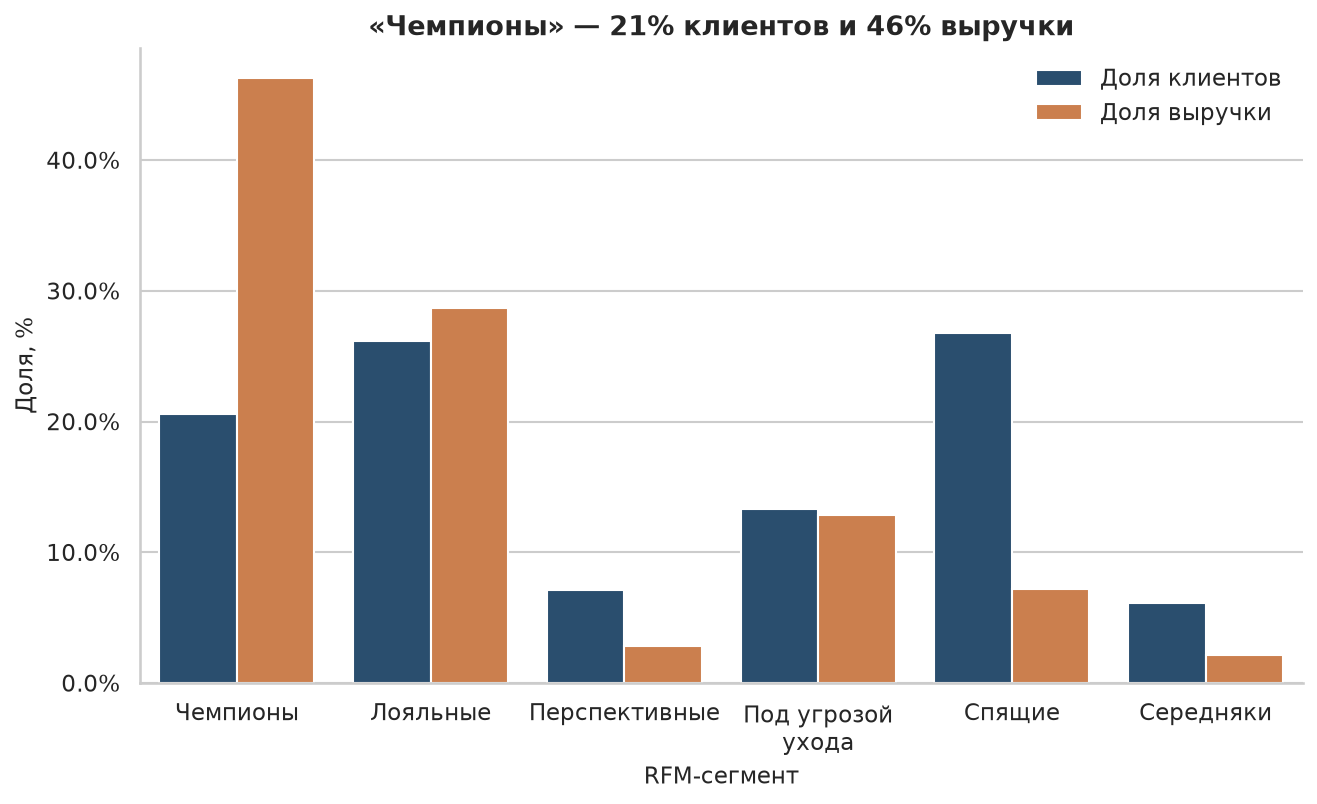

«Чемпионы» — 21% домохозяйств и 46% выручки, вместе с «Лояльными» — 75% выручки. «Спящие» многочисленны (27% клиентов), но дают 7% выручки. «Под угрозой ухода» — 13% клиентов с высокой исторической частотой (105 чеков в среднем) и 13% выручки: это главный резерв для реактивации.

In [9]:
show("rfm_segments", rfm)
display(Markdown(
    f"«{champions.name}» — {champions['household_share']:.0%} домохозяйств и {champions['revenue_share']:.0%} выручки, "
    f"вместе с «Лояльными» — {segments.loc[['Чемпионы', 'Лояльные'], 'revenue_share'].sum():.0%} выручки. "
    f"«Спящие» многочисленны ({segments.loc['Спящие', 'household_share']:.0%} клиентов), но дают "
    f"{segments.loc['Спящие', 'revenue_share']:.0%} выручки. «Под угрозой ухода» — {at_risk['household_share']:.0%} клиентов "
    f"с высокой исторической частотой ({at_risk['avg_frequency']:.0f} чеков в среднем) и {at_risk['revenue_share']:.0%} выручки: "
    f"это главный резерв для реактивации."
))

## 5. Как удерживаются клиенты?

**Метод.** `sql/04_cohorts.sql`: когорта — 4-недельный период первой покупки (`MIN() OVER`),
удержание — доля домохозяйств когорты с покупкой в каждом следующем периоде. Используются
только полные периоды до конца окна. Когорты меньше порога из `config.yaml` отброшены.

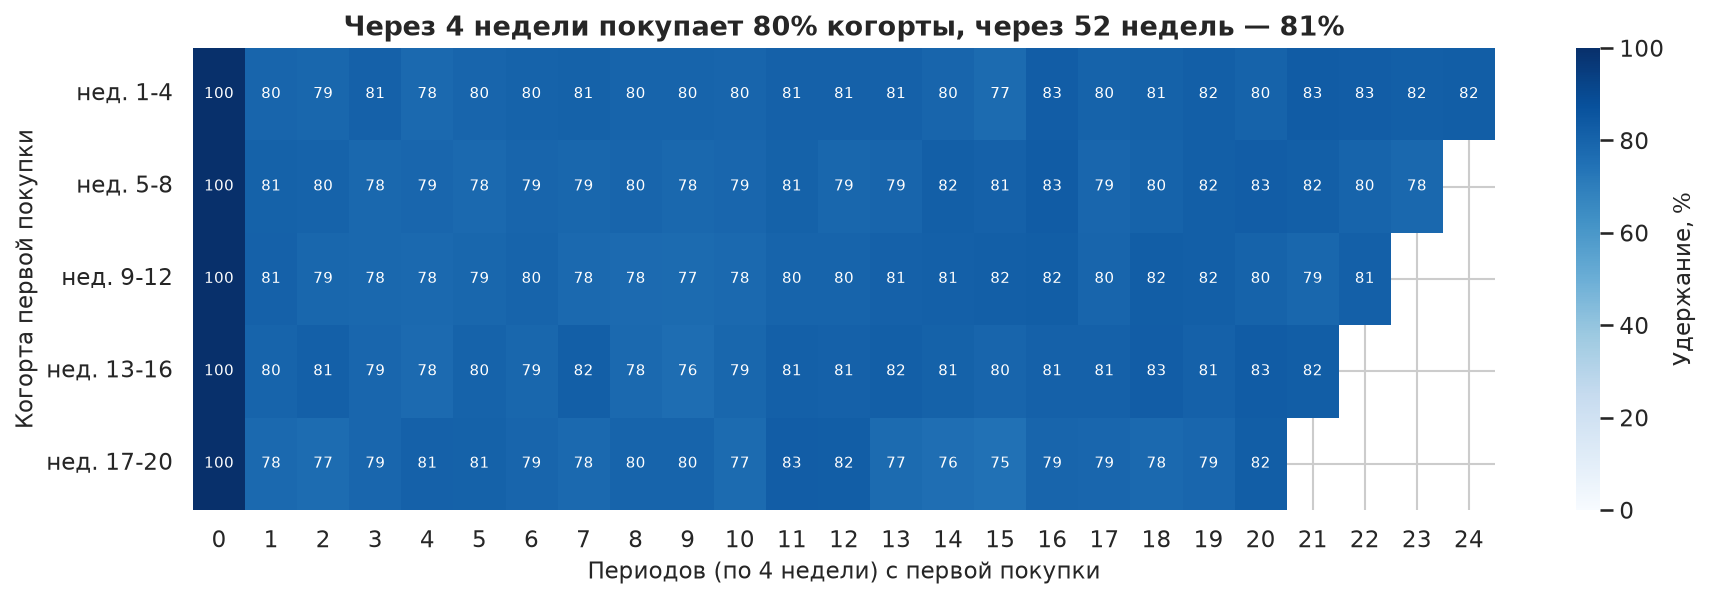

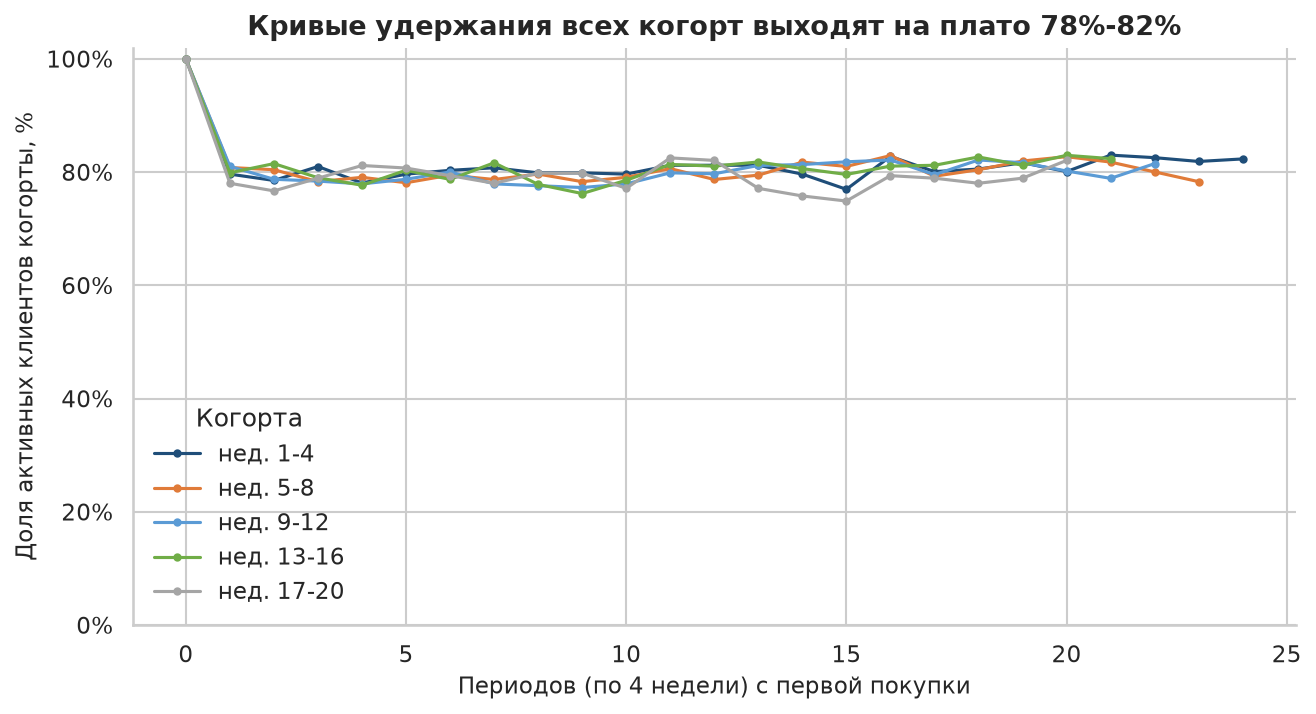

Сохранено когорт: 5 (2488 домохозяйств); в отброшенных мелких когортах — 12 домохозяйств. Все сохраненные когорты — первые недели наблюдения (нед. 1-4, нед. 5-8, нед. 9-12, нед. 13-16, нед. 17-20), то есть когорта здесь — момент входа в панель, а не привлечение нового клиента. После первого периода удержание держится в диапазоне 78%–82% и не снижается: через год покупает 81% когорты. Панель dunnhumby отобрана из частых покупателей, поэтому для всей клиентской базы сети это верхняя граница удержания.

In [10]:
show("cohort_heatmap", cohorts)
show("cohort_lines", cohorts)
display(Markdown(
    f"Сохранено когорт: {cohorts['cohorts_kept']} ({cohorts['households_in_kept_cohorts']} домохозяйств); "
    f"в отброшенных мелких когортах — {cohorts['households_in_dropped_cohorts']} домохозяйств. "
    f"Все сохраненные когорты — первые недели наблюдения ({', '.join(cohorts['cohort_sizes'])}), то есть когорта здесь — "
    f"момент входа в панель, а не привлечение нового клиента. После первого периода удержание держится "
    f"в диапазоне {cohorts['retention_plateau_min']:.0%}–{cohorts['retention_plateau_max']:.0%} и не снижается: "
    f"через год покупает {retention['13']:.0%} когорты. Панель dunnhumby отобрана из частых покупателей, "
    f"поэтому для всей клиентской базы сети это верхняя граница удержания."
))

## 6. Работают ли промоакции?

**Дизайн (stacked difference-in-differences).**

* **Воздействие:** товар в каталоге (`mailer` не равен `0`) не менее чем в половине магазинов в
  неделю промо и ни разу за 4 предшествующие недели.
* **Контроль:** товары той же подкатегории (`sub_commodity_desc`), не бывшие в каталоге во всем окне.
* **Окно:** 4 недели до промо и неделя промо; в выборке только товары с продажами во все 4 недели
  до промо (иначе нельзя отличить отсутствие спроса от отсутствия товара).
* **Модель:** `log(1 + продажи) ~ treated × post` с фиксированными эффектами товара и недели внутри
  каждого события, стандартные ошибки кластеризованы по товару.
* **Каннибализация:** та же методика, где «воздействие» — непромо-товары подкатегории, в которой
  вышло новое промо, а контроль — товары других подкатегорий той же товарной категории без промо.
* Топливо и прочие операции (`KIOSK-GAS`, `MISC SALES TRAN`) исключены: там `quantity` — не штуки.

In [11]:
effects = pd.DataFrame(estimates).T[
    ["effect_pct", "effect_pct_ci_low", "effect_pct_ci_high", "p_value", "events", "treated_units", "control_units", "clusters"]
]
display(effects)

,effect_pct,effect_pct_ci_low,effect_pct_ci_high,p_value,events,treated_units,control_units,clusters
units,100.404,95.174,105.773,0.000,3056,8315,19241,6687
revenue,84.182,79.111,89.396,0.000,3056,8315,19241,6687
units_display_control,48.430,44.603,52.357,0.000,3056,8315,19241,6687
cannibalization_units,2.174,-0.381,4.794,0.096,988,5196,7916,4827


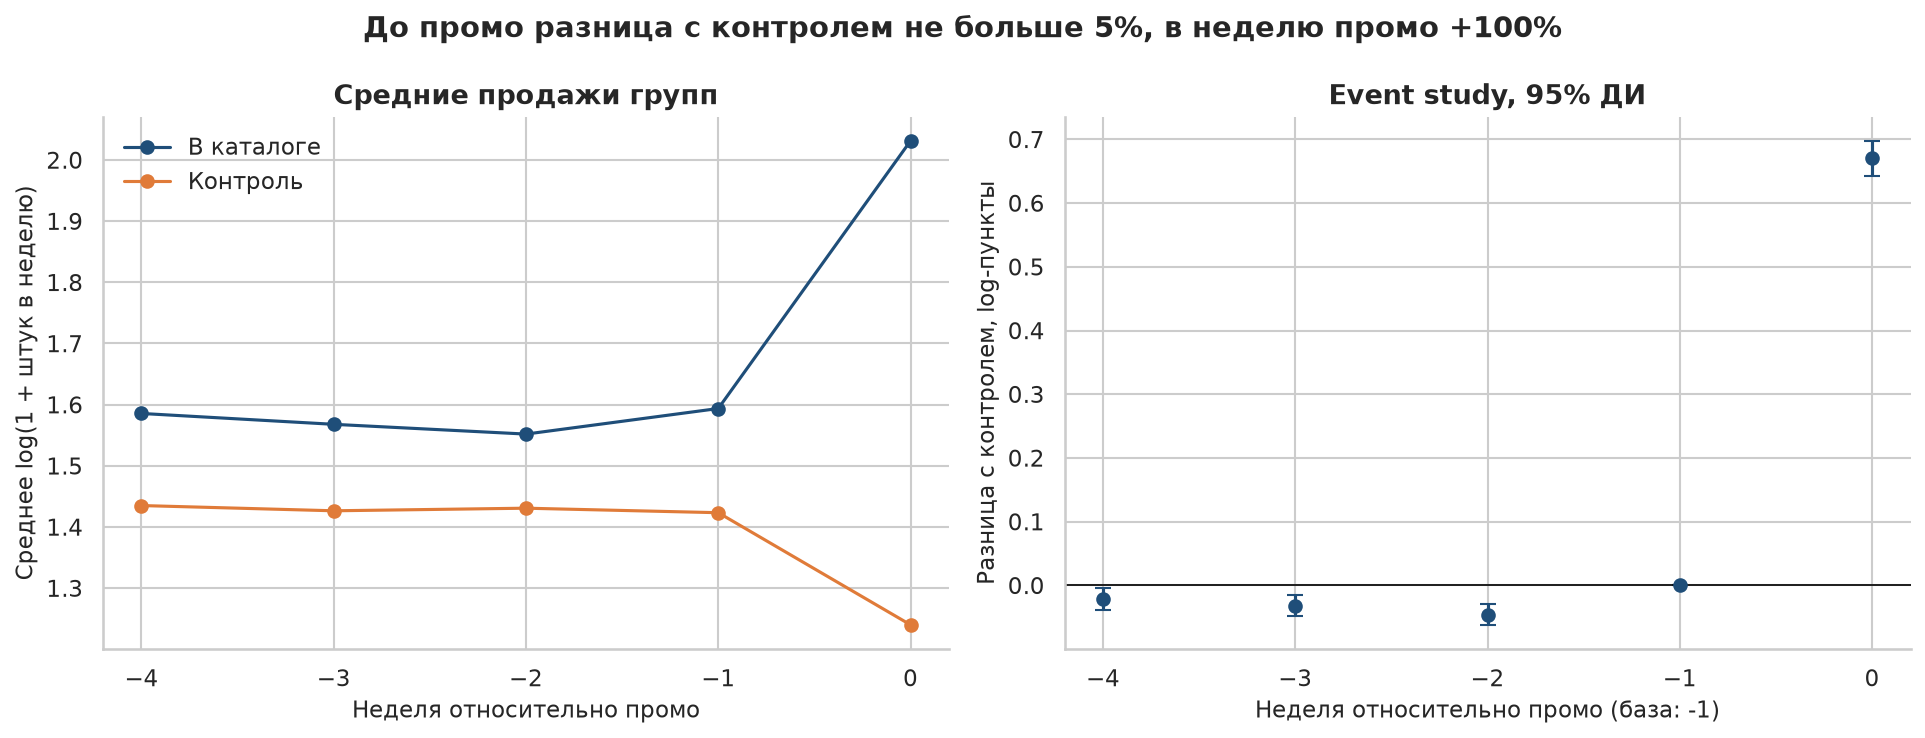

**Параллельные тренды.** До промо разница между группами меняется не больше чем на 4.7% (event-study, база — неделя −1), а в неделю промо скачок +100%. Однако совместный тест равенства нулю предпромо-коэффициентов отвергает параллельность (p = 4e-07): товары, которые ставят в каталог, слегка ускоряются в неделю перед промо. Это ограничение: точная величина эффекта может быть завышена на несколько процентных пунктов, но не меняет его порядок. Падение средних продаж обеих групп в неделю промо — артефакт отбора (условие продаж во все предпромо-недели), он одинаков для групп и вычитается в DiD.

In [12]:
show("promo_trends", promo)
display(Markdown(
    f"**Параллельные тренды.** До промо разница между группами меняется не больше чем на "
    f"{promo['max_pre_period_gap_pct']:.1f}% (event-study, база — неделя −1), а в неделю промо скачок "
    f"{units['effect_pct']:+.0f}%. Однако совместный тест равенства нулю предпромо-коэффициентов отвергает "
    f"параллельность (p = {promo['pretrend_joint_p_value']:.1g}): товары, которые ставят в каталог, слегка "
    f"ускоряются в неделю перед промо. Это ограничение: точная величина эффекта может быть завышена на "
    f"несколько процентных пунктов, но не меняет его порядок. Падение средних продаж обеих групп в неделю "
    f"промо — артефакт отбора (условие продаж во все предпромо-недели), он одинаков для групп и "
    f"вычитается в DiD."
))

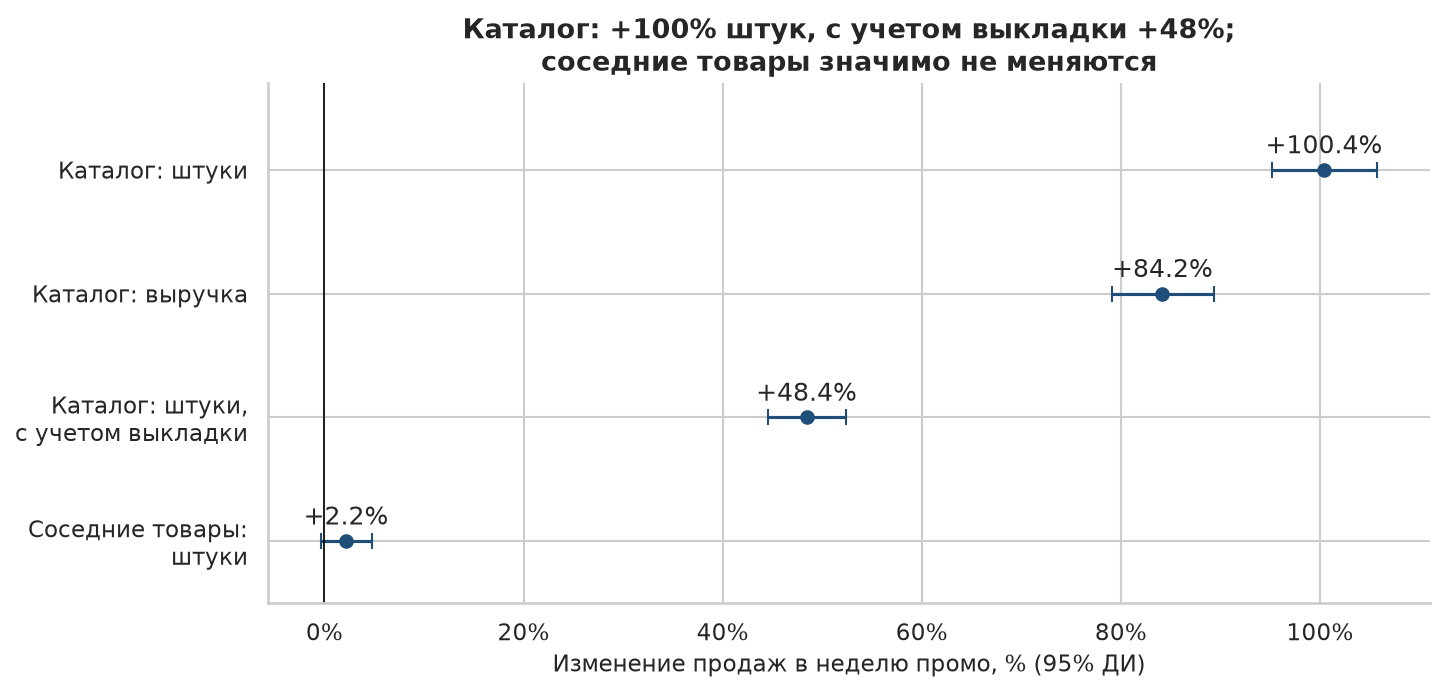

Каталог: +100.4% штук (95% ДИ 95.2–105.8%) и +84.2% выручки — выручка растет меньше штук, что согласуется со скидкой на промо-товар. 90% товаров каталога в неделю промо одновременно в выкладке (контроль — 45%); с контролем на долю магазинов с выкладкой эффект каталога +48.4% (95% ДИ 44.6–52.4%). Каннибализация: значимой каннибализации соседних товаров нет: +2.2% (95% ДИ от -0.4% до +4.8%); предпромо-тренды в этом дизайне параллельны (p = 0.95).

In [13]:
show("promo_effects", promo)
display(Markdown(
    f"Каталог: {units['effect_pct']:+.1f}% штук (95% ДИ {units['effect_pct_ci_low']:.1f}–{units['effect_pct_ci_high']:.1f}%) "
    f"и {revenue['effect_pct']:+.1f}% выручки — выручка растет меньше штук, что согласуется со скидкой на промо-товар. "
    f"{promo['concurrent_display_share']['treated']:.0%} товаров каталога в неделю промо одновременно в выкладке "
    f"(контроль — {promo['concurrent_display_share']['control']:.0%}); с контролем на долю магазинов с выкладкой "
    f"эффект каталога {with_display['effect_pct']:+.1f}% (95% ДИ {with_display['effect_pct_ci_low']:.1f}–"
    f"{with_display['effect_pct_ci_high']:.1f}%). Каннибализация: {cannibal_text}; предпромо-тренды в этом "
    f"дизайне параллельны (p = {promo['cannibalization_pretrend_joint_p_value']:.2f})."
))

## 7. Уходящие лояльные клиенты

**Определение** (`sql/05_churning_loyal.sql`, параметры в `config.yaml`): лояльный — в верхних 20%
домохозяйств по выручке за первую половину окна; уходящий — в последние 12 недель число чеков
меньше половины его же среднего за 12 недель в предыдущей части окна.

,households,revenue,baseline_revenue,recent_revenue,baseline_baskets,recent_baskets,household_share,revenue_share,baseline_revenue_share,recent_revenue_share,avg_basket_value
household_group,,,,,,,,,,,
churning_loyal,70,"434,252.160","410,925.020","23,327.140",38.539,9.757,0.028,0.058,0.065,0.021,25.074
other,2002,"3,610,117.520","3,021,100.980","589,016.540",9.884,10.452,0.803,0.484,0.476,0.529,25.255
stable_loyal,421,"3,419,900.790","2,919,065.850","500,834.940",31.152,30.955,0.169,0.458,0.460,0.450,36.418


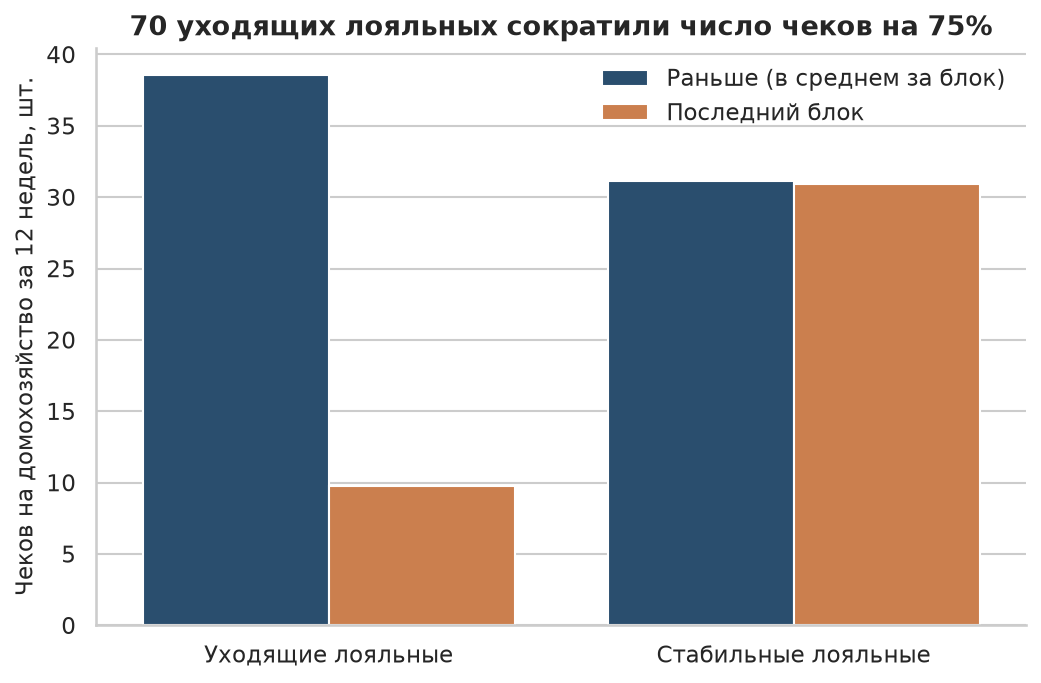

In [14]:
display(groups)
show("loyal_activity", churn)

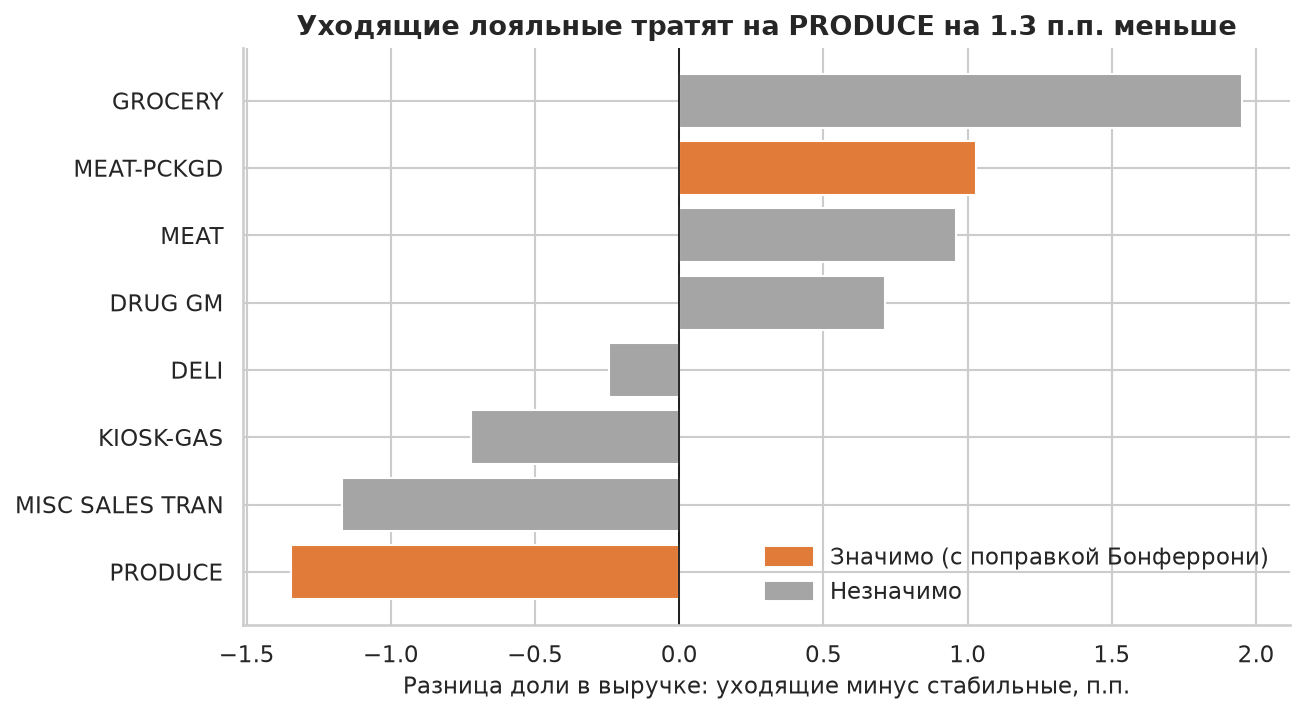

,department,churning_share,stable_share,difference_pp,p_value,significant
0,GROCERY,0.511,0.492,1.951,0.089,False
1,DRUG GM,0.138,0.130,0.712,0.283,False
2,KIOSK-GAS,0.079,0.087,-0.722,0.993,False
3,PRODUCE,0.057,0.071,-1.347,0.002,True
4,MEAT,0.073,0.064,0.958,0.108,False
5,MEAT-PCKGD,0.057,0.047,1.028,0.002,True
6,DELI,0.031,0.034,-0.244,0.113,False
7,MISC SALES TRAN,0.006,0.018,-1.171,0.824,False


,attribute,churning_with_demographics,stable_with_demographics,p_value,min_expected_count,reliable,significant
0,classification_1,30,303,0.098,1.351,False,False
1,classification_2,30,303,0.329,3.874,False,False
2,classification_3,30,303,0.000,0.180,False,False
3,classification_4,30,303,0.483,2.252,False,False
4,classification_5,30,303,0.433,1.892,False,False
5,homeowner_desc,30,303,0.200,0.180,False,False
6,kid_category_desc,30,303,0.539,2.703,False,False


In [15]:
show("churning_departments", churn)
display(department_mix)
display(demographics)

In [16]:
basket = churn["basket_value_comparison"]
reliable = demographics[demographics["reliable"]]
significant_demo = demographics[demographics["significant"]]
demo_text = (
    "значимых демографических различий нет"
    if significant_demo.empty
    else "значимые различия: " + ", ".join(significant_demo["attribute"])
)
display(Markdown(
    f"**Кто они.** {churn['churning_households']} домохозяйств — {churn['churning_households'] / churn['loyal_households']:.0%} лояльных. "
    f"В базовый период они давали {churn['churning_baseline_revenue_share']:.1%} выручки, в последние "
    f"{churn['recent_weeks']} недель — {churn['churning_recent_revenue_share']:.1%}. Средний чек ниже, чем у стабильных лояльных "
    f"(медиана {basket['churning_median']:.1f} $ против {basket['stable_median']:.1f} $, тест Манна–Уитни p = {basket['p_value']:.1g}). "
    f"В структуре корзины значимы (с поправкой Бонферрони) только: {mix_text}. "
    f"Демография есть лишь у {int(demographics['churning_with_demographics'].iloc[0])} уходящих домохозяйств; "
    f"χ²-тест надежен (ожидаемые частоты от {config.churning_loyal.min_expected_count}) для {len(reliable)} из {len(demographics)} признаков, "
    f"{demo_text}. Признаки в этой версии датасета анонимизированы (`classification_1`–`classification_5`).\n\n"
    f"**Что делать.** Отслеживать частоту покупок каждого лояльного клиента относительно его собственной нормы и "
    f"запускать удерживающую кампанию при падении вдвое; в предложениях учитывать категории, где корзина этой "
    f"группы отличается ({mix_text}). Эффект кампании проверять на контрольной группе."
))

**Кто они.** 70 домохозяйств — 14% лояльных. В базовый период они давали 6.5% выручки, в последние 12 недель — 2.1%. Средний чек ниже, чем у стабильных лояльных (медиана 28.4 $ против 40.1 $, тест Манна–Уитни p = 2e-05). В структуре корзины значимы (с поправкой Бонферрони) только: PRODUCE -1.3 п.п., MEAT-PCKGD +1.0 п.п.. Демография есть лишь у 30 уходящих домохозяйств; χ²-тест надежен (ожидаемые частоты от 5) для 0 из 7 признаков, значимых демографических различий нет. Признаки в этой версии датасета анонимизированы (`classification_1`–`classification_5`).

**Что делать.** Отслеживать частоту покупок каждого лояльного клиента относительно его собственной нормы и запускать удерживающую кампанию при падении вдвое; в предложениях учитывать категории, где корзина этой группы отличается (PRODUCE -1.3 п.п., MEAT-PCKGD +1.0 п.п.). Эффект кампании проверять на контрольной группе.

## 8. Ограничения и что бы я сделал дальше

**Ограничения**

* **Панель, а не вся база.** 2 500 домохозяйств, отобранных из частых покупателей; удержание и
  доли сегментов нельзя переносить на всех клиентов сети.
* **Нет календаря.** Только номера дней и недель, поэтому сезонность и праздники не учитываются явно.
* **Промо назначается не случайно.** В каталог ставят товары, на которые ожидается спрос; DiD
  убирает постоянные различия между товарами, но не решение «поставить товар в каталог именно сейчас».
  Предтренды близки, но формально не параллельны.
* **Одновременные акции.** Каталог почти всегда совпадает с выкладкой и, вероятно, со скидкой.
  Цены до скидки для всех товаров нет (есть только `retail_disc` по факту покупки панели), поэтому
  эффект каталога нельзя отделить от эффекта цены.
* **Продажи — только панель.** Продажи товара считаются по покупкам 2 500 домохозяйств, а не по всем
  чекам магазинов; малопродаваемые товары не проходят фильтр доступности.
* **Демография анонимизирована** и есть только у части домохозяйств.

**Что дальше**

* Разделить эффекты каталога, выкладки и цены: добавить фактическую цену из `sales_value / quantity`
  и `retail_disc`, оценить модель с взаимодействиями.
* Оценить эффект в неделях после промо (pull-forward: не «съедает» ли промо будущие продажи).
* Посчитать прирост маржи, а не выручки, если доступна себестоимость.
* Построить модель раннего предупреждения ухода лояльных клиентов и проверить ее на отложенном периоде.
* Использовать `campaign_table` и `coupon_redempt` для оценки адресных кампаний.